# Refine SILVA taxonomy with SpeciateIT and plot CST/Nugent heatmap

This notebook does two things:

1. Refines the exported SILVA taxonomy using the SpeciateIT classification table. Species-like SpeciateIT labels with confidence `>= 0.80` are used as deeper species-level overrides while keeping the SILVA higher-rank context.
2. Uses the BIOM feature table and the curated Nugent metadata to collapse feature counts by refined taxon, assign vaginal community state types (CSTs), and plot a heatmap with CST and Nugent annotations.

Outputs are written to `results/10_cst_heatmap/`.

In [1]:
from pathlib import Path
import os
import re

PROJECT_ROOT = Path('/home/rare/arlen/16S_colombian_vaginal_microbiome')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/cst_heatmap_matplotlib_cache')

import numpy as np
import pandas as pd
from biom import load_table
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_rgb, to_hex, LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import pdist, squareform

SILVA_TAXONOMY_TSV = PROJECT_ROOT / 'results/08_exported_files/silva_taxonomy/b2966e3c-a2a5-4ed0-9a18-96a0bcc8e8f4/data/taxonomy.tsv'
SPECIATEIT_RESULTS_TXT = PROJECT_ROOT / 'results/09_speciate_it_classification/MC_order7_results.txt'
FEATURE_TABLE_BIOM = PROJECT_ROOT / 'results/08_exported_files/table.qza/7baea51d-54ab-4bcf-b314-03b787993a95/data/feature-table.biom'
METADATA_TSV = PROJECT_ROOT / 'data/input_files/manifest_curated_nugent.tsv'
OUTPUT_DIR = PROJECT_ROOT / 'results/10_cst_heatmap'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPECIES_CONFIDENCE_MIN = 0.80
GENUS_CONFIDENCE_MIN = 0.70
DOMINANT_CST_THRESHOLD = 0.30
TOP_N_TAXA = 40

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 160)

## Load input files

The QIIME2 metadata type row (`#q2:types`) is removed before joining Nugent values to the BIOM samples.

In [2]:
silva_taxonomy = pd.read_csv(SILVA_TAXONOMY_TSV, sep='	')
speciateit = pd.read_csv(
    SPECIATEIT_RESULTS_TXT,
    sep='	',
    header=None,
    names=['Feature ID', 'speciateit_taxon', 'speciateit_confidence', 'speciateit_order'],
)
metadata = pd.read_csv(METADATA_TSV, sep='	', dtype=str)
metadata = metadata[metadata.iloc[:, 0].ne('#q2:types')].copy()

biom_table = load_table(str(FEATURE_TABLE_BIOM))
biom_feature_ids = pd.Index(biom_table.ids(axis='observation'), name='Feature ID')
biom_sample_ids = pd.Index(biom_table.ids(axis='sample'), name='sample-id')

print(f'SILVA taxonomy rows: {len(silva_taxonomy):,}')
print(f'SpeciateIT rows: {len(speciateit):,}')
print(f'BIOM shape: {biom_table.shape[0]:,} features x {biom_table.shape[1]:,} samples')
print(f'Metadata samples: {len(metadata):,}')
print(f'SILVA features matched in BIOM: {silva_taxonomy["Feature ID"].isin(biom_feature_ids).sum():,}')
print(f'SpeciateIT features matched in BIOM: {speciateit["Feature ID"].isin(biom_feature_ids).sum():,}')
print(f'Metadata samples matched in BIOM: {metadata["sample-id"].isin(biom_sample_ids).sum():,}')

SILVA taxonomy rows: 971
SpeciateIT rows: 971
BIOM shape: 971 features x 55 samples
Metadata samples: 55
SILVA features matched in BIOM: 971
SpeciateIT features matched in BIOM: 971
Metadata samples matched in BIOM: 55


## Refine taxonomy

Rule used here:

- Keep the original SILVA taxonomy as the base classification.
- If SpeciateIT provides a species-like label with confidence `>= SPECIES_CONFIDENCE_MIN`, replace the SILVA genus/species fields with the SpeciateIT genus/species.
- If SILVA has no genus and SpeciateIT gives a genus-level label with confidence `>= GENUS_CONFIDENCE_MIN`, fill the genus.
- Export both an audit table and a QIIME-style taxonomy table.

In [3]:
RANK_PREFIXES = [
    ('d', 'domain'),
    ('p', 'phylum'),
    ('c', 'class'),
    ('o', 'order'),
    ('f', 'family'),
    ('g', 'genus'),
    ('s', 'species'),
]
PREFIX_TO_RANK = {prefix: rank for prefix, rank in RANK_PREFIXES}


def clean_rank_value(value):
    if pd.isna(value):
        return pd.NA
    value = str(value).strip()
    if not value or value.lower() in {'nan', 'none', 'uncultured', 'unidentified', 'metagenome'}:
        return pd.NA
    return value


def parse_qiime_taxon(taxon):
    parsed = {rank: pd.NA for _, rank in RANK_PREFIXES}
    for token in str(taxon).split(';'):
        token = token.strip()
        if '__' not in token:
            continue
        prefix, value = token.split('__', 1)
        rank = PREFIX_TO_RANK.get(prefix)
        if rank:
            parsed[rank] = clean_rank_value(value)
    return pd.Series(parsed)


def parse_speciateit_label(label):
    label = str(label).strip()
    prefixed = re.match(r'^([dpcogf])_(.+)$', label)
    if prefixed:
        prefix, raw_name = prefixed.groups()
        rank = PREFIX_TO_RANK[prefix]
        name = raw_name.replace('_', ' ').strip()
        result = {
            'speciateit_rank': rank,
            'speciateit_name': name,
            'speciateit_genus': pd.NA,
            'speciateit_species': pd.NA,
        }
        if rank == 'genus':
            result['speciateit_genus'] = name
        return pd.Series(result)

    tokens = label.split('_')
    if len(tokens) < 2:
        return pd.Series({
            'speciateit_rank': 'unknown',
            'speciateit_name': label,
            'speciateit_genus': pd.NA,
            'speciateit_species': pd.NA,
        })

    if tokens[0] == 'Ca' and len(tokens) >= 3:
        genus = 'Candidatus ' + tokens[1]
        species = 'Candidatus ' + ' '.join(tokens[1:])
    elif len(tokens) >= 3 and len(tokens[1]) == 1 and tokens[1].isalpha() and not (len(tokens[-1]) == 1 and tokens[-1].isalpha()):
        genus = f'{tokens[0]} {tokens[1]}'
        species = ' '.join(tokens)
    else:
        genus = tokens[0]
        species = ' '.join(tokens)

    return pd.Series({
        'speciateit_rank': 'species',
        'speciateit_name': species,
        'speciateit_genus': genus,
        'speciateit_species': species,
    })


def make_taxon_string(row):
    parts = []
    for prefix, rank in RANK_PREFIXES:
        value = row.get(rank, pd.NA)
        value = '' if pd.isna(value) else str(value).strip()
        parts.append(f'{prefix}__{value}')
    return ';'.join(parts)


def best_display_taxon(row):
    for rank in ['species', 'genus', 'family', 'order', 'class', 'phylum', 'domain']:
        value = row.get(rank, pd.NA)
        if pd.notna(value) and str(value).strip():
            if rank == 'species':
                return str(value)
            return f'{value} ({rank})'
    return 'Unclassified'

In [4]:
parsed_silva = silva_taxonomy['Taxon'].apply(parse_qiime_taxon)
parsed_speciateit = speciateit['speciateit_taxon'].apply(parse_speciateit_label)

refined = pd.concat([silva_taxonomy, parsed_silva], axis=1).merge(
    pd.concat([speciateit, parsed_speciateit], axis=1),
    on='Feature ID',
    how='left',
)
refined['original_silva_taxon'] = refined['Taxon']
refined['refinement_source'] = 'SILVA unchanged'

species_mask = refined['speciateit_rank'].eq('species') & refined['speciateit_confidence'].ge(SPECIES_CONFIDENCE_MIN)
refined.loc[species_mask, 'genus'] = refined.loc[species_mask, 'speciateit_genus']
refined.loc[species_mask, 'species'] = refined.loc[species_mask, 'speciateit_species']
refined.loc[species_mask, 'refinement_source'] = 'SpeciateIT species override'

genus_mask = (
    refined['species'].isna()
    & refined['genus'].isna()
    & refined['speciateit_rank'].eq('genus')
    & refined['speciateit_confidence'].ge(GENUS_CONFIDENCE_MIN)
)
refined.loc[genus_mask, 'genus'] = refined.loc[genus_mask, 'speciateit_genus']
refined.loc[genus_mask, 'refinement_source'] = 'SpeciateIT genus fill'

refined['refined_taxon'] = refined.apply(make_taxon_string, axis=1)
refined['display_taxon'] = refined.apply(best_display_taxon, axis=1)
refined['refined_confidence'] = np.where(
    refined['refinement_source'].str.startswith('SpeciateIT'),
    refined['speciateit_confidence'],
    refined['Confidence'],
)

refined['refinement_source'].value_counts()

refinement_source
SpeciateIT species override    502
SILVA unchanged                469
Name: count, dtype: int64

In [5]:
refined_export_cols = [
    'Feature ID',
    'original_silva_taxon',
    'Confidence',
    'speciateit_taxon',
    'speciateit_confidence',
    'speciateit_order',
    'refinement_source',
    'refined_taxon',
    'display_taxon',
    'refined_confidence',
]

refined_audit_path = OUTPUT_DIR / 'refined_taxonomy_audit.tsv'
refined_qiime_path = OUTPUT_DIR / 'refined_taxonomy_qiime.tsv'

refined[refined_export_cols].to_csv(refined_audit_path, sep='	', index=False)
refined[['Feature ID', 'refined_taxon', 'refined_confidence']].rename(
    columns={'refined_taxon': 'Taxon', 'refined_confidence': 'Confidence'}
).to_csv(refined_qiime_path, sep='	', index=False)

print(refined_audit_path)
print(refined_qiime_path)
refined[refined_export_cols].head(10)

/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/refined_taxonomy_audit.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/refined_taxonomy_qiime.tsv


,Feature ID,original_silva_taxon,Confidence,speciateit_taxon,speciateit_confidence,speciateit_order,refinement_source,refined_taxon,display_taxon,refined_confidence
0,08e8ed3a513a88b5599f505242a281eb,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__,0.994378,Lactobacillus_iners,0.97,46,SpeciateIT species override,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__Lactobacillus iners,Lactobacillus iners,0.97
1,244bee25b63f157f89f1e97e608f5c47,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__,0.999947,Lactobacillus_crispatus,0.97,46,SpeciateIT species override,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__Lactobacillus crispatus,Lactobacillus crispatus,0.97
2,f6c0d5e255fc23b608315df8e9efe557,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__,0.999992,Gardnerella_vaginalis,0.97,27,SpeciateIT species override,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__Gardnerella vaginalis,Gardnerella vaginalis,0.97
3,64b421b8072426aaddfb8b937fa0ed27,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__,0.999989,Gardnerella_vaginalis,0.97,27,SpeciateIT species override,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__Gardnerella vaginalis,Gardnerella vaginalis,0.97
4,b24cd5a63c535ff4e55a2506d3cd62bb,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__,0.999998,Gardnerella_vaginalis,0.98,27,SpeciateIT species override,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__Gardnerella vaginalis,Gardnerella vaginalis,0.98
5,be014e630e00e5c6e3f0ca87daa86d1b,d__Bacteria;p__Actinobacteriota;c__Coriobacteriia;o__Coriobacteriales;f__Atopobiaceae;g__Atopobium;s__,0.994023,Fannyhessea_vaginae,0.98,24,SpeciateIT species override,d__Bacteria;p__Actinobacteriota;c__Coriobacteriia;o__Coriobacteriales;f__Atopobiaceae;g__Fannyhessea;s__Fannyhessea vaginae,Fannyhessea vaginae,0.98
6,3c53f93a8518ea184d549ebf34217b9d,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__,0.997451,Lactobacillus_jensenii,0.98,46,SpeciateIT species override,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__Lactobacillus jensenii,Lactobacillus jensenii,0.98
7,96f9d59d4d210fbeb71ba39924965ac1,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__,0.999997,Gardnerella_vaginalis,0.98,27,SpeciateIT species override,d__Bacteria;p__Actinobacteriota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Gardnerella;s__Gardnerella vaginalis,Gardnerella vaginalis,0.98
8,f3ca08f9bbac735a9686685ad95f238e,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__,0.793693,Lactobacillus_gasseri,0.98,46,SpeciateIT species override,d__Bacteria;p__Firmicutes;c__Bacilli;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus;s__Lactobacillus gasseri,Lactobacillus gasseri,0.98
9,2156fb6df9754022915f729e6be6dacb,d__Bacteria;p__Firmicutes;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Shuttleworthia;s__,0.997911,Ca_Lachnocurva_vaginae,0.97,185,SpeciateIT species override,d__Bacteria;p__Firmicutes;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Candidatus Lachnocurva;s__Candidatus Lachnocurva vaginae,Candidatus Lachnocurva vaginae,0.97


## Collapse feature table by refined taxon

The BIOM table is converted to a feature-by-sample count matrix, then features are collapsed using the refined display taxon. Relative abundance tables are saved as fractions and percentages.

In [6]:
feature_counts = pd.DataFrame(
    biom_table.matrix_data.toarray(),
    index=biom_table.ids(axis='observation'),
    columns=biom_table.ids(axis='sample'),
)
feature_to_taxon = refined.set_index('Feature ID')['display_taxon']
missing_taxonomy = feature_counts.index.difference(feature_to_taxon.index)
if len(missing_taxonomy):
    raise ValueError(f'{len(missing_taxonomy)} BIOM features are missing taxonomy.')

taxon_counts = feature_counts.assign(display_taxon=feature_to_taxon).groupby('display_taxon', sort=False).sum()
relative_abundance = taxon_counts.div(taxon_counts.sum(axis=0), axis=1).fillna(0)

relative_abundance_path = OUTPUT_DIR / 'species_relative_abundance.tsv'
relative_abundance_percent_path = OUTPUT_DIR / 'species_relative_abundance_percent.tsv'
relative_abundance.to_csv(relative_abundance_path, sep='	')
(relative_abundance * 100).to_csv(relative_abundance_percent_path, sep='	')

print(f'Collapsed taxa: {relative_abundance.shape[0]:,}')
print(relative_abundance_path)
print(relative_abundance_percent_path)

species_level_taxa_preview = refined.loc[refined['species'].notna(), 'display_taxon'].dropna().unique()
species_level_preview = relative_abundance.loc[
    relative_abundance.index.intersection(species_level_taxa_preview)
]
print(f'Species-level taxa available for plotting: {species_level_preview.shape[0]:,}')
(species_level_preview.mean(axis=1).sort_values(ascending=False).head(15) * 100).round(2).to_frame('mean_relative_abundance_percent')

Collapsed taxa: 314
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/species_relative_abundance.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/species_relative_abundance_percent.tsv
Species-level taxa available for plotting: 219


,mean_relative_abundance_percent
display_taxon,
Lactobacillus iners,27.65
Gardnerella vaginalis,27.14
Lactobacillus crispatus,15.96
Fannyhessea vaginae,4.39
Lactobacillus gasseri,3.05
Candidatus Lachnocurva vaginae,2.22
Lactobacillus jensenii,1.75
Escherichia coli,1.13
Megasphaera lornae,1.04


## Assign CSTs and add Nugent metadata

CST assignment is based on dominant refined taxa:

- CST I: `Lactobacillus crispatus`
- CST II: `Lactobacillus gasseri`
- CST III: `Lactobacillus iners`
- CST V: `Lactobacillus jensenii`
- CST IV: diverse or anaerobe/BV-associated communities not meeting the Lactobacillus marker threshold

The Nugent score is not used to overwrite sequence-based CST calls. It is joined as a clinical/microscopy annotation and summarized in `CST_Nugent_profile`.

In [7]:
CST_MARKERS = {
    'Lactobacillus crispatus': 'CST I',
    'Lactobacillus gasseri': 'CST II',
    'Lactobacillus iners': 'CST III',
    'Lactobacillus jensenii': 'CST V',
}
BV_ASSOCIATED_KEYWORDS = (
    'Gardnerella',
    'Fannyhessea',
    'Atopobium',
    'Megasphaera',
    'Sneathia',
    'Prevotella',
    'Mobiluncus',
    'Dialister',
    'Anaerococcus',
    'Peptoniphilus',
)


def assign_cst(sample_ra):
    top_taxon = sample_ra.idxmax()
    top_abundance = float(sample_ra.max())
    marker_values = {taxon: float(sample_ra.get(taxon, 0.0)) for taxon in CST_MARKERS}
    best_marker = max(marker_values, key=marker_values.get)
    best_marker_abundance = marker_values[best_marker]
    lactobacillus_total = float(sample_ra[sample_ra.index.str.startswith('Lactobacillus ')].sum())

    if best_marker_abundance >= DOMINANT_CST_THRESHOLD and best_marker_abundance >= top_abundance * 0.80:
        return pd.Series({
            'CST': CST_MARKERS[best_marker],
            'CST_detail': f'{CST_MARKERS[best_marker]}: {best_marker} dominated',
            'dominant_taxon': top_taxon,
            'dominant_relative_abundance': top_abundance,
            'cst_marker_taxon': best_marker,
            'cst_marker_relative_abundance': best_marker_abundance,
            'lactobacillus_relative_abundance': lactobacillus_total,
        })

    if any(keyword in top_taxon for keyword in BV_ASSOCIATED_KEYWORDS):
        cst_detail = f'CST IV-B: anaerobe/BV-associated, top taxon {top_taxon}'
    else:
        cst_detail = f'CST IV-A: diverse, top taxon {top_taxon}'

    return pd.Series({
        'CST': 'CST IV',
        'CST_detail': cst_detail,
        'dominant_taxon': top_taxon,
        'dominant_relative_abundance': top_abundance,
        'cst_marker_taxon': best_marker,
        'cst_marker_relative_abundance': best_marker_abundance,
        'lactobacillus_relative_abundance': lactobacillus_total,
    })

In [8]:
assignments = relative_abundance.apply(assign_cst, axis=0).T
assignments.index.name = 'sample-id'

metadata_nugent = metadata.set_index('sample-id')[
    ['nugent_score_estimated', 'nugent_category_estimated', 'nugent_score_method']
].copy()
metadata_nugent['nugent_score_estimated'] = pd.to_numeric(
    metadata_nugent['nugent_score_estimated'],
    errors='coerce',
)
assignments = assignments.join(metadata_nugent, how='left')

numeric_cols = [
    'dominant_relative_abundance',
    'cst_marker_relative_abundance',
    'lactobacillus_relative_abundance',
]
assignments[numeric_cols] = assignments[numeric_cols].astype(float)
assignments['CST_Nugent_profile'] = (
    assignments['CST'] + ' | Nugent ' + assignments['nugent_category_estimated'].fillna('missing')
)

assignments_path = OUTPUT_DIR / 'sample_cst_assignments.tsv'
assignments.to_csv(assignments_path, sep='	')

print(assignments_path)
print(assignments['CST'].value_counts().to_string())
assignments.head(15)

/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/sample_cst_assignments.tsv
CST
CST IV     27
CST III    16
CST I      10
CST II      2


,CST,CST_detail,dominant_taxon,dominant_relative_abundance,cst_marker_taxon,cst_marker_relative_abundance,lactobacillus_relative_abundance,nugent_score_estimated,nugent_category_estimated,nugent_score_method,CST_Nugent_profile
sample-id,,,,,,,,,,,
CGV001,CST I,CST I: Lactobacillus crispatus dominated,Lactobacillus crispatus,0.927079,Lactobacillus crispatus,0.927079,0.977212,1,normal,estimated_from_morphotype_grades_blank_as_absent,CST I | Nugent normal
CGV002,CST I,CST I: Lactobacillus crispatus dominated,Lactobacillus crispatus,0.976815,Lactobacillus crispatus,0.976815,0.981210,1,normal,estimated_from_morphotype_grades_blank_as_absent,CST I | Nugent normal
CGV003,CST IV,"CST IV-A: diverse, top taxon Escherichia coli",Escherichia coli,0.189802,Lactobacillus iners,0.101983,0.220963,1,normal,estimated_from_morphotype_grades_blank_as_absent,CST IV | Nugent normal
CGV004,CST III,CST III: Lactobacillus iners dominated,Lactobacillus iners,0.888113,Lactobacillus iners,0.888113,0.975146,1,normal,estimated_from_morphotype_grades_blank_as_absent,CST III | Nugent normal
CGV005,CST III,CST III: Lactobacillus iners dominated,Lactobacillus iners,0.728602,Lactobacillus iners,0.728602,0.729422,0,normal,estimated_from_morphotype_grades_blank_as_absent,CST III | Nugent normal
CGV006,CST IV,"CST IV-A: diverse, top taxon Lactobacillus crispatus",Lactobacillus crispatus,0.181818,Lactobacillus crispatus,0.181818,0.268939,1,normal,estimated_from_morphotype_grades_blank_as_absent,CST IV | Nugent normal
CGV007,CST IV,"CST IV-B: anaerobe/BV-associated, top taxon Gardnerella vaginalis",Gardnerella vaginalis,0.541518,Lactobacillus iners,0.056823,0.088292,3,normal,estimated_from_morphotype_grades_blank_as_absent,CST IV | Nugent normal
CGV008,CST I,CST I: Lactobacillus crispatus dominated,Lactobacillus crispatus,0.984497,Lactobacillus crispatus,0.984497,0.989034,0,normal,estimated_from_morphotype_grades_blank_as_absent,CST I | Nugent normal
CGV009,CST III,CST III: Lactobacillus iners dominated,Lactobacillus iners,0.974448,Lactobacillus iners,0.974448,0.976362,1,normal,estimated_from_morphotype_grades_blank_as_absent,CST III | Nugent normal


## Plot heatmap

Samples are clustered by Bray-Curtis distance across species-level refined taxa only, with an added between-CST distance penalty so CST color blocks stay grouped while samples remain clustered within each CST. The top annotation bars are generated in the same sample order as the heatmap columns. Genus-level fallback rows and aggregate `Other` rows are excluded from this plot.

In [9]:
species_level_taxa = refined.loc[refined['species'].notna(), 'display_taxon'].dropna().unique()
species_relative_abundance = relative_abundance.loc[
    relative_abundance.index.intersection(species_level_taxa)
].copy()
if species_relative_abundance.empty:
    raise ValueError('No species-level taxa are available for the heatmap.')

mandatory_species = [taxon for taxon in CST_MARKERS if taxon in species_relative_abundance.index]
top_species = species_relative_abundance.mean(axis=1).sort_values(ascending=False).head(TOP_N_TAXA).index.tolist()
plot_species = list(dict.fromkeys(mandatory_species + top_species))[:TOP_N_TAXA]

plot_pct_unordered = species_relative_abundance.loc[plot_species]
plot_pct_unordered = plot_pct_unordered.loc[plot_pct_unordered.max(axis=1).gt(0)] * 100

if plot_pct_unordered.shape[1] > 1:
    abundance_dist = squareform(pdist(plot_pct_unordered.T, metric='braycurtis'))
    sample_csts = assignments.reindex(plot_pct_unordered.columns)['CST'].fillna('Unassigned')
    cst_penalty = (sample_csts.to_numpy()[:, None] != sample_csts.to_numpy()[None, :]).astype(float) * 2.0
    cst_aware_dist = abundance_dist + cst_penalty
    col_linkage = linkage(squareform(cst_aware_dist, checks=False), method='average')
else:
    col_linkage = None

plot_pct = plot_pct_unordered.copy()

plot_pct.shape

(40, 55)

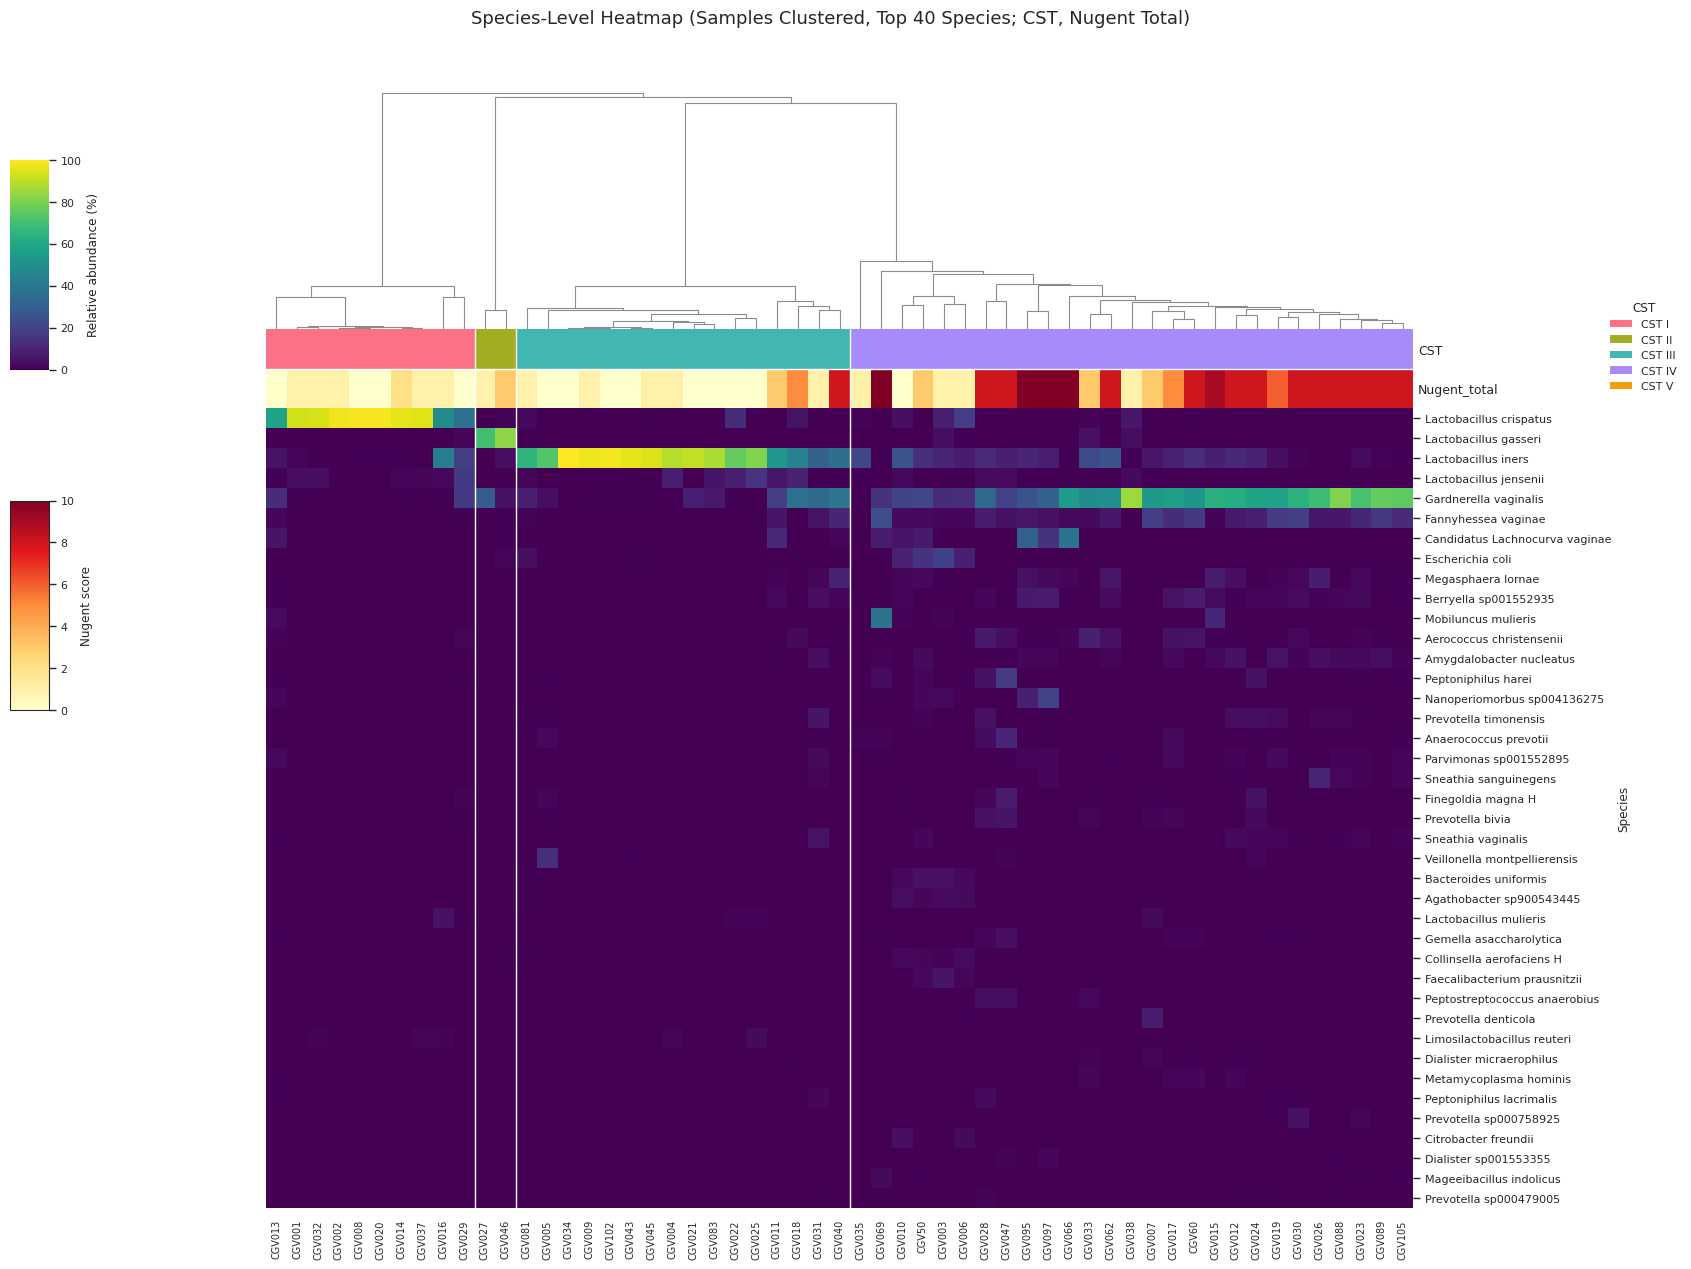

/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/cst_refined_taxonomy_heatmap.png
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/cst_refined_taxonomy_heatmap.pdf
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/clustered_heatmap_sample_order.tsv


In [10]:
sns.set_theme(context='paper', style='white', font_scale=0.9)
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
})

RELATIVE_ABUNDANCE_CMAP = plt.get_cmap('viridis')
NUGENT_SCORE_CMAP = LinearSegmentedColormap.from_list(
    'nugent_score',
    ['#ffffcc', '#fed976', '#fd8d3c', '#e31a1c', '#800026'],
    N=256,
)

CST_ORDER = ['CST I', 'CST II', 'CST III', 'CST IV', 'CST V']
CST_PALETTE = {
    'CST I': '#fb7185',
    'CST II': '#a3ad23',
    'CST III': '#41b6b3',
    'CST IV': '#a78bfa',
    'CST V': '#f59e0b',
}
score_cmap = NUGENT_SCORE_CMAP
score_norm = Normalize(vmin=0, vmax=10)


def nugent_score_to_color(score):
    if pd.isna(score):
        return '#d9d9d9'
    return to_hex(score_cmap(score_norm(float(score))))


annotation_metadata = assignments.reindex(plot_pct.columns)
col_colors = pd.DataFrame(
    {
        'CST': annotation_metadata['CST'].map(CST_PALETTE).fillna('#d9d9d9'),
        'Nugent_total': annotation_metadata['nugent_score_estimated'].apply(nugent_score_to_color),
    },
    index=plot_pct.columns,
)

fig_width = max(13, 0.23 * plot_pct.shape[1] + 5)
fig_height = max(10, 0.24 * plot_pct.shape[0] + 3.5)
plt.close('all')

g = sns.clustermap(
    plot_pct,
    row_cluster=False,
    col_cluster=col_linkage is not None,
    col_linkage=col_linkage,
    col_colors=col_colors,
    cmap=RELATIVE_ABUNDANCE_CMAP,
    vmin=0,
    vmax=100,
    xticklabels=True,
    yticklabels=True,
    figsize=(fig_width, fig_height),
    dendrogram_ratio=(0.015, 0.22),
    colors_ratio=(0.015, 0.035),
    cbar_pos=(0.035, 0.72, 0.022, 0.16),
    cbar_kws={'label': 'Relative abundance (%)', 'ticks': [0, 20, 40, 60, 80, 100]},
    tree_kws={'linewidths': 0.8, 'colors': '#8c8c8c'},
)

g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('Species')
g.ax_heatmap.yaxis.tick_right()
g.ax_heatmap.yaxis.set_label_position('right')
g.ax_heatmap.tick_params(axis='x', labelsize=7, rotation=90)
g.ax_heatmap.tick_params(axis='y', labelsize=8)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_col_colors.set_yticks([0.5, 1.5])
g.ax_col_colors.set_yticklabels(['CST', 'Nugent_total'], fontsize=9)
g.ax_col_colors.yaxis.tick_right()
g.ax_col_colors.tick_params(axis='y', length=0)
for y in [1]:
    g.ax_col_colors.axhline(y, color='white', linewidth=1.0)

g.ax_col_dendrogram.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
for spine in g.ax_col_dendrogram.spines.values():
    spine.set_visible(False)

plotted_csts = set(annotation_metadata['CST'].dropna())
cst_handles = [
    Patch(facecolor=CST_PALETTE[label], edgecolor='none', label=label)
    for label in CST_ORDER
    if label in plotted_csts
]
g.fig.legend(handles=cst_handles, title='CST', loc='upper right', bbox_to_anchor=(0.985, 0.78), frameon=False)

score_mappable = plt.cm.ScalarMappable(norm=score_norm, cmap=score_cmap)
score_mappable.set_array([])
score_cax = g.fig.add_axes([0.04, 0.45, 0.025, 0.18])
score_cbar = g.fig.colorbar(score_mappable, cax=score_cax, ticks=[0, 2, 4, 6, 8, 10])
score_cbar.set_label('Nugent score')

clustered_sample_order = (
    plot_pct.columns[g.dendrogram_col.reordered_ind].tolist()
    if col_linkage is not None
    else plot_pct.columns.tolist()
)
pd.Series(clustered_sample_order, name='sample-id').to_csv(
    OUTPUT_DIR / 'clustered_heatmap_sample_order.tsv',
    sep='\t',
    index=False,
)
plot_pct.loc[:, clustered_sample_order].to_csv(
    OUTPUT_DIR / 'species_level_heatmap_relative_abundance_percent.tsv',
    sep='\t',
)

ordered_csts = assignments.reindex(clustered_sample_order)['CST'].fillna('Unassigned').to_numpy()
cst_boundaries = np.flatnonzero(ordered_csts[1:] != ordered_csts[:-1]) + 1
for boundary in cst_boundaries:
    g.ax_heatmap.axvline(boundary, color='white', linewidth=1.0)
    g.ax_col_colors.axvline(boundary, color='white', linewidth=1.0)

g.fig.suptitle(
    f'Species-Level Heatmap (Samples Clustered, Top {TOP_N_TAXA} Species; CST, Nugent Total)',
    y=0.995,
    fontsize=13,
)
g.fig.subplots_adjust(top=0.94, bottom=0.08, left=0.17, right=0.83)
g.cax.set_position([0.035, 0.72, 0.022, 0.16])
score_cax.set_position([0.035, 0.46, 0.022, 0.16])

heatmap_png = OUTPUT_DIR / 'cst_refined_taxonomy_heatmap.png'
heatmap_pdf = OUTPUT_DIR / 'cst_refined_taxonomy_heatmap.pdf'
g.fig.savefig(heatmap_png, dpi=600, bbox_inches='tight')
g.fig.savefig(heatmap_pdf, bbox_inches='tight')
plt.show()

print(heatmap_png)
print(heatmap_pdf)
print(OUTPUT_DIR / 'clustered_heatmap_sample_order.tsv')

## Output files

Generated files:

- `refined_taxonomy_audit.tsv`: original SILVA taxonomy, SpeciateIT result, refinement source, and refined taxonomy.
- `refined_taxonomy_qiime.tsv`: QIIME-compatible taxonomy table with `Feature ID`, `Taxon`, and `Confidence`.
- `species_relative_abundance.tsv`: refined-taxon relative abundance as fractions.
- `species_relative_abundance_percent.tsv`: refined-taxon relative abundance as percentages.
- `sample_cst_assignments.tsv`: per-sample CST assignment joined to Nugent score/category.
- `clustered_heatmap_sample_order.tsv`: sample order used in the clustered heatmap.
- `species_level_heatmap_relative_abundance_percent.tsv`: species-only heatmap matrix, with columns in plotted order.
- `cst_refined_taxonomy_heatmap.png` and `.pdf`: heatmap figure.

In [11]:
for output_file in sorted(OUTPUT_DIR.glob('*')):
    print(output_file)

/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/clustered_heatmap_sample_order.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/cst_refined_taxonomy_heatmap.pdf
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/cst_refined_taxonomy_heatmap.png
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/refined_taxonomy_audit.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/refined_taxonomy_qiime.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/sample_cst_assignments.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/species_level_heatmap_relative_abundance_percent.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/species_relative_abundance.tsv
/home/rare/arlen/16S_colombian_vaginal_microbiome/results/10_cst_heatmap/species_relative_abundance_percent.tsv
